# Проект модуля. Нейросеть для автодополнения текстов

In [78]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
np.random.seed(42)

from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
torch.manual_seed(42)

## Загрузка и подготовка данных

In [1]:
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

In [17]:
print("Размеры выборок:")
print(f"Train: {len(dataset['train'])} примеров")
print(f"Validation: {len(dataset['validation'])} примеров")
print(f"Test: {len(dataset['test'])} примеров")

# Посмотрим пример текста
print("\nПример текста из train:")
print(dataset['train'][3]['text'])

Размеры выборок:
Train: 36718 примеров
Validation: 3760 примеров
Test: 4358 примеров

Пример текста из train:
 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . 



In [26]:
sentences_number = [len(text.split('.')) for text in dataset['train']['text'] if text.strip()]
print('Общее число предложений', sum(sentences_number))
print('Среднее число предложений', sum(sentences_number)/len(sentences_number))

Общее число предложений 108058
Среднее число предложений 4.546556149282619


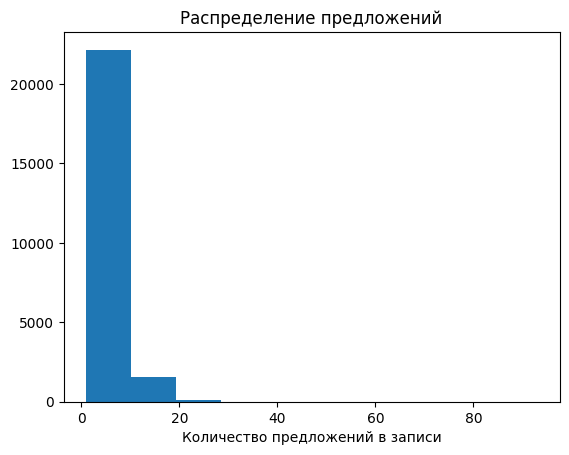

In [31]:
plt.hist(sentences_number)
plt.xlabel('Количество предложений в записи')
plt.title('Распределение предложений');

In [65]:
class WordTokenizer:
    """Простой пословный токенизатор с контролем частоты"""
    def __init__(self, min_freq=2, max_vocab_size=None):
        self.min_freq = min_freq
        self.max_vocab_size = max_vocab_size
        self.word2idx = {}
        self.idx2word = {}
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'
        self.bos_token = '<BOS>'
        self.eos_token = '<EOS>'
        
    def build_vocab(self, texts):
        """Построение словаря на основе частоты слов"""
        # Считаем частоты всех слов
        word_counts = Counter()
        for text in texts:
            if text.strip():
                words = text.lower().split()
                word_counts.update(words)
        
        # Отбираем слова с частотой >= min_freq
        vocab_words = [word for word, count in word_counts.items() 
                      if count >= self.min_freq]
        
        # Ограничиваем размер словаря
        if self.max_vocab_size:
            vocab_words = vocab_words[:self.max_vocab_size]
        
        # Создаем словари
        special_tokens = [self.pad_token, self.unk_token, self.bos_token, self.eos_token]
        all_tokens = special_tokens + vocab_words
        
        self.word2idx = {word: idx for idx, word in enumerate(all_tokens)}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        
        print(f"Размер словаря: {len(self.word2idx)}")
        print(f"Спец. токены: {special_tokens}")
        print(f"Обычных слов: {len(vocab_words)}")
        
    def encode(self, text, add_bos=True, add_eos=True):
        """Текст -> список индексов"""
        if not text.strip():
            return []
        
        words = text.lower().split()
        indices = []
        
        if add_bos:
            indices.append(self.word2idx[self.bos_token])
            
        for word in words:
            idx = self.word2idx.get(word, self.word2idx[self.unk_token])
            indices.append(idx)
            
        if add_eos:
            indices.append(self.word2idx[self.eos_token])
            
        return indices
    
    def decode(self, indices, skip_special=True):
        """Список индексов -> текст"""
        words = []
        for idx in indices:
            word = self.idx2word[idx]
            if skip_special and word in [self.pad_token, self.bos_token, self.eos_token]:
                continue
            words.append(word)
        return ' '.join(words)

# Создаем токенизатор
tokenizer = WordTokenizer(min_freq=3, max_vocab_size=20000)

# Строим словарь на обучающей выборке
print("\nПостроение словаря на train...")
tokenizer.build_vocab(dataset['train']['text'])

# Примеры работы
sample_text = dataset['train'][5]['text']
print(f"\nОригинальный текст: {sample_text[:100]}")
encoded = tokenizer.encode(sample_text, add_bos=True, add_eos=True)
print(f"Закодирован: {encoded[:20]}")  # первые 20 токенов
decoded = tokenizer.decode(encoded[:20])
print(f"Декодирован: {decoded}")


Построение словаря на train...
Размер словаря: 20004
Спец. токены: ['<PAD>', '<UNK>', '<BOS>', '<EOS>']
Обычных слов: 20000

Оригинальный текст:  It met with positive sales in Japan , and was praised by both Japanese and western critics . After 
Закодирован: [2, 49, 137, 122, 138, 139, 46, 28, 16, 40, 133, 140, 38, 116, 14, 40, 141, 142, 18, 143]
Декодирован: it met with positive sales in japan , and was praised by both japanese and western critics . after


In [36]:
def create_sequences(tokenizer, texts, seq_len=32):
    all_indices = []
    
    for text in tqdm(texts, desc="Токенизация"):
        if text.strip():
            indices = tokenizer.encode(text, add_bos=True, add_eos=False)
            all_indices.extend(indices)
    
    X = []
    Y = []
    
    for i in range(0, len(all_indices) - seq_len, seq_len // 2):
        input_seq = all_indices[i:i + seq_len - 1]
        target_seq = all_indices[i + 1:i + seq_len]
        
        if len(input_seq) == seq_len - 1 and len(target_seq) == seq_len - 1:
            X.append(input_seq)
            Y.append(target_seq)
    
    return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long)

In [38]:
SEQ_LEN = 32
print(f"\nСоздание последовательностей длины {SEQ_LEN}")

X_train, y_train = create_sequences(tokenizer, dataset['train']['text'], SEQ_LEN)
X_val, y_val = create_sequences(tokenizer, dataset['validation']['text'], SEQ_LEN)
X_test, y_test = create_sequences(tokenizer, dataset['test']['text'], SEQ_LEN)

print(f"Train: {X_train.shape}, Предсказываем {SEQ_LEN-1} слов")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")


Создание последовательностей длины 32


Токенизация: 100%|██████████| 4358/4358 [00:00<00:00, 71624.46it/s]


Train: torch.Size([129728, 31]), Предсказываем 31 слов
Val: torch.Size([13520, 31])
Test: torch.Size([15255, 31])


In [43]:
X_train.shape, y_train.shape

(torch.Size([129728, 31]), torch.Size([129728, 31]))

In [39]:
class WikiDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [44]:
train_dataset = WikiDataset(X_train, y_train)
val_dataset = WikiDataset(X_val, y_val)
test_dataset = WikiDataset(X_test, y_test)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Реализация и обучение LSTM

In [48]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, rnn_type="LSTM"):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        if rnn_type=='GRU':
            self.rnn = nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True)
        else:
            self.rnn = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, vocab_size)


    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)

        linear_out = self.fc(out)

        return linear_out

In [49]:
def compute_loss_and_perplexity(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            logits = model(x)

            logits = logits.view(-1, logits.size(-1))
            y = y.view(-1)

            loss = criterion(logits, y)

            total_loss += loss.item() * y.size(0)
            total_tokens += y.size(0)
        
    avg_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(avg_loss))

    return avg_loss, perplexity.item()

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, clip=1.0, device='cuda'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_perplexities = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        train_tokens = 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            logits = logits.view(-1, logits.size(-1))
            y = y.view(-1)

            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optimizer.step()

            total_train_loss += loss.item() * y.size(0)
            train_tokens += y.size(0)

            progress_bar.set_postfix({'loss':loss.item()})
        
        avg_train_loss = total_train_loss / train_tokens
        
        val_loss, val_perp = compute_loss_and_perplexity(model, val_loader, criterion, device)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        val_perplexities.append(val_perp)
        
        print(f'Epoch {epoch+1}/{epochs}')
        print(f'Train Loss: {avg_train_loss:.4f}')
        print(f'Val Loss: {val_loss:.4f}')
        print(f'Val Perplexity: {val_perp:.2f}')
        print()
    
    return train_losses, val_losses, val_perplexities

In [51]:
epochs = 10
lr = 0.001
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Используем устройство:', device)

Используем устройство: cuda


In [52]:
def plot_training_curves(train_losses, val_losses, val_perplexities, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(train_losses, label='Train Loss', marker='o')
    axes[0].plot(val_losses, label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross Entropy Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Perplexity
    axes[1].plot(val_perplexities, label='Val Perplexity', marker='^', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Perplexity')
    axes[1].set_title(f'{model_name} - Validation Perplexity')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

Размер словаря: 20004
Начинаем обучение LSTM...


Epoch 1/10: 100%|██████████| 2027/2027 [00:24<00:00, 83.29it/s, loss=5.86]


Epoch 1/10
  Train Loss: 6.2289
  Val Loss: 5.8014
  Val Perplexity: 330.76



Epoch 2/10: 100%|██████████| 2027/2027 [00:23<00:00, 85.35it/s, loss=5.17]


Epoch 2/10
  Train Loss: 5.5641
  Val Loss: 5.4018
  Val Perplexity: 221.82



...

Epoch 8/10
  Train Loss: 4.2503
  Val Loss: 5.0572
  Val Perplexity: 157.15



Epoch 9/10: 100%|██████████| 2027/2027 [00:24<00:00, 82.95it/s, loss=4.04]


Epoch 9/10
  Train Loss: 4.1444
  Val Loss: 5.0908
  Val Perplexity: 162.52



Epoch 10/10: 100%|██████████| 2027/2027 [00:24<00:00, 81.62it/s, loss=4.06]


Epoch 10/10
  Train Loss: 4.0500
  Val Loss: 5.1319
  Val Perplexity: 169.34



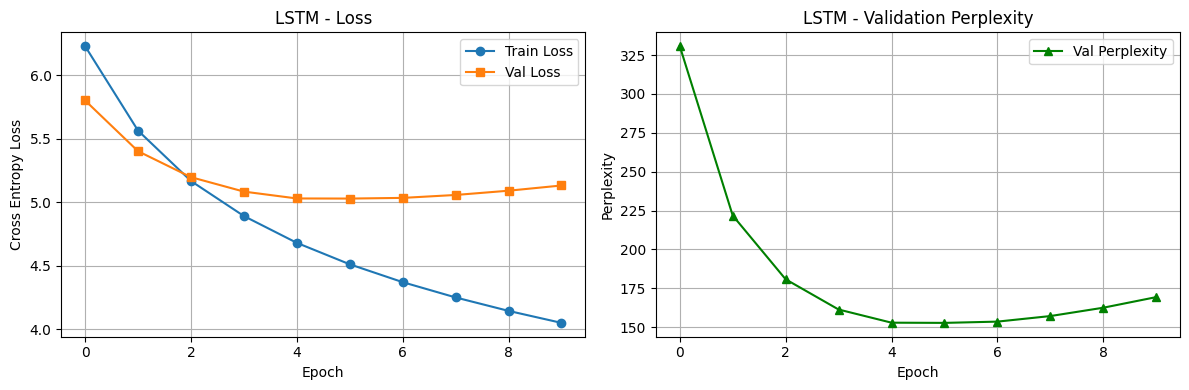

In [53]:
vocab_size = len(tokenizer.word2idx)
print('Размер словаря:', vocab_size)

lstm_model = RNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    rnn_type='LSTM'
)

print('Начинаем обучение LSTM...')
lstm_train_losses, lstm_val_losses, lstm_val_perps = train_model(lstm_model, train_loader, val_loader, epochs=epochs, lr=lr, device=device)

plot_training_curves(lstm_train_losses, lstm_val_losses, lstm_val_perps, "LSTM")

In [60]:
print('Количество параметров модели LSTM:', sum(p.numel() for p in lstm_model.parameters()))

Количество параметров модели LSTM: 8623140


## Эксперимент: GRU vs LSTM

Начинаем обучение GRU...


Epoch 1/10: 100%|██████████| 2027/2027 [00:23<00:00, 87.48it/s, loss=5.72]


Epoch 1/10
  Train Loss: 5.9960
  Val Loss: 5.5356
  Val Perplexity: 253.57



Epoch 2/10: 100%|██████████| 2027/2027 [00:24<00:00, 83.76it/s, loss=4.91]


Epoch 2/10
  Train Loss: 5.2173
  Val Loss: 5.1802
  Val Perplexity: 177.72



...

Epoch 8/10
  Train Loss: 3.8869
  Val Loss: 5.2138
  Val Perplexity: 183.79



Epoch 9/10: 100%|██████████| 2027/2027 [00:23<00:00, 86.07it/s, loss=3.83]


Epoch 9/10
  Train Loss: 3.7887
  Val Loss: 5.2717
  Val Perplexity: 194.75



Epoch 10/10: 100%|██████████| 2027/2027 [00:23<00:00, 86.20it/s, loss=3.77]


Epoch 10/10
  Train Loss: 3.7047
  Val Loss: 5.3326
  Val Perplexity: 206.97



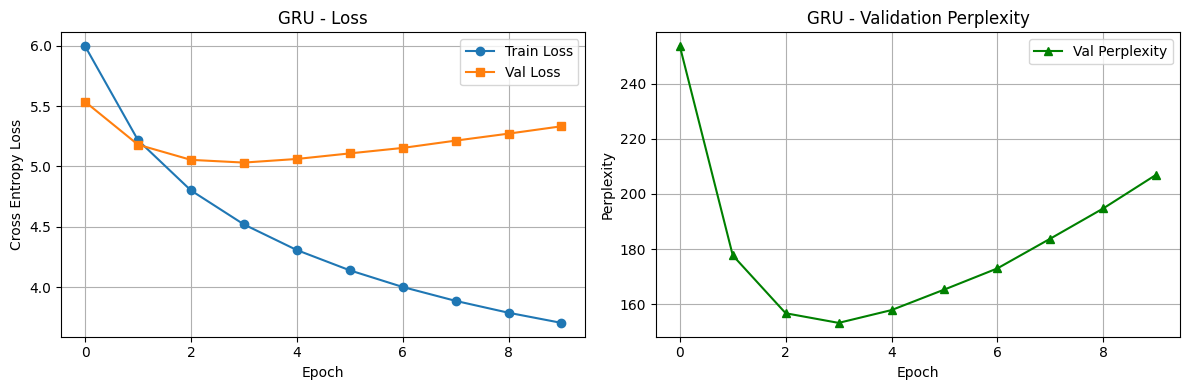

In [61]:
gru_model = RNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    rnn_type='GRU'
)

print('Начинаем обучение GRU...')
gru_train_losses, gru_val_losses, gru_val_perps = train_model(gru_model, train_loader, val_loader, epochs=epochs, lr=lr, device=device)

plot_training_curves(gru_train_losses, gru_val_losses, gru_val_perps, "GRU")

In [63]:
print('Количество параметров модели GRU:', sum(p.numel() for p in gru_model.parameters()))

Количество параметров модели GRU: 8392740


Количество параметров, как и должно быть, меньше в GRU, соответственно, и время на эпоху также меньше, но не существенно в нашей задаче. Однако эта разница может иметь большое значении при масштабировании моделей. Также видно, что в обеих моделях есть переобучение, причем в GRu оно наступает раньше. В остальном - результаты обеих моделей очень сопоставимы, в том числе в плане метрик.

## Оценка distilgpt2

In [ ]:
test_texts = dataset['test']['text']

# Фильтруем пустые строки
test_texts = [text for text in test_texts if text.strip()]
print(f"Всего тестовых примеров: {len(test_texts)}")

Всего тестовых примеров: 2891


In [71]:
def calculate_perplexity_distilgpt2(model, tokenizer, texts, batch_size=32):
    model.eval()
    total_loss = 0
    total_length = 0
    
    device = next(model.parameters()).device
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Вычисление perplexity"):
        batch_texts = texts[i:i+batch_size]
        
        # Токенизируем
        encodings = tokenizer(
            batch_texts,
            return_tensors='pt',
            truncation=True,
            max_length=512,
            padding=True
        )
        
        input_ids = encodings.input_ids.to(device)
        attention_mask = encodings.attention_mask.to(device)
        
        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = input_ids[..., 1:].contiguous()
            shift_attention_mask = attention_mask[..., 1:].contiguous()
            
            loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
            loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), 
                           shift_labels.view(-1))
            
            loss = loss.view(shift_labels.size())
            loss = (loss * shift_attention_mask).sum() / shift_attention_mask.sum()
            
            total_loss += loss.item() * shift_attention_mask.sum().item()
            total_length += shift_attention_mask.sum().item()
    
    avg_loss = total_loss / total_length
    perplexity = np.exp(avg_loss)
    
    return avg_loss, perplexity

print("Загрузка distilgpt2")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

distilgpt2_tokenizer = GPT2TokenizerFast.from_pretrained("distilgpt2")
distilgpt2_model = GPT2LMHeadModel.from_pretrained("distilgpt2")
distilgpt2_model = distilgpt2_model.to(device)

# Устанавливаем pad_token
distilgpt2_tokenizer.pad_token = distilgpt2_tokenizer.eos_token

# Вычисляем perplexity на тестовой выборке
print("\nВычисление perplexity для distilgpt2")
test_loss, test_perplexity = calculate_perplexity_distilgpt2(
    distilgpt2_model,
    distilgpt2_tokenizer,
    test_texts,
    batch_size=32
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Perplexity: {test_perplexity:.2f}")

Загрузка distilgpt2
Используем устройство: cuda

Вычисление perplexity для distilgpt2


Вычисление perplexity: 100%|██████████| 91/91 [04:24<00:00,  2.91s/it]

Test Loss: 4.3098
Test Perplexity: 74.42


In [76]:
test_contexts = [
    "the president of the",
    "i want to",
    "the weather today is",
    "new york is a",
    "in the beginning",
    "artificial intelligence is",
    "the united states",
    "she said that",
]

def predict_gpt2(context, top_k=5):
    distilgpt2_model.eval()
    with torch.no_grad():
        inputs = distilgpt2_tokenizer(context, return_tensors='pt').to(device)
        outputs = distilgpt2_model(**inputs)
        logits = outputs.logits[0, -1, :]
        probs = torch.softmax(logits, dim=-1)
        top_probs, top_indices = torch.topk(probs, top_k)
        
        predictions = []
        for i in range(top_k):
            word = distilgpt2_tokenizer.decode([top_indices[i].item()]).strip()
            prob = top_probs[i].item()
            predictions.append((word, prob))
        return predictions

print("Предсказания предоюученной модели")

for context in test_contexts:
    print(f"\nКонтекст: '{context}'")
    print("Предсказания:")
    predictions = predict_gpt2(context)
    for i, (word, prob) in enumerate(predictions[:3], 1):
        print(f"  {i}. '{word}' (вероятность: {prob:.3f})")
    print("-"*40)

Предсказания предоюученной модели

Контекст: 'the president of the'
Предсказания:
  1. 'United' (вероятность: 0.602)
  2. 'U' (вероятность: 0.037)
  3. 'US' (вероятность: 0.023)
----------------------------------------

Контекст: 'i want to'
Предсказания:
  1. 'be' (вероятность: 0.056)
  2. 'see' (вероятность: 0.055)
  3. 'make' (вероятность: 0.041)
----------------------------------------

Контекст: 'the weather today is'
Предсказания:
  1. 'a' (вероятность: 0.051)
  2. 'the' (вероятность: 0.044)
  3. 'very' (вероятность: 0.035)
----------------------------------------

Контекст: 'new york is a'
Предсказания:
  1. 'very' (вероятность: 0.018)
  2. 'new' (вероятность: 0.018)
  3. 'great' (вероятность: 0.018)
----------------------------------------

Контекст: 'in the beginning'
Предсказания:
  1. 'of' (вероятность: 0.689)
  2. '.' (вероятность: 0.087)
  3. ',' (вероятность: 0.059)
----------------------------------------

Контекст: 'artificial intelligence is'
Предсказания:
  1. 'a' (ве

## Сравнение и выводы

In [77]:
def predict_next_word(model, tokenizer, context, model_type='lstm', top_k=5):
    if model_type == 'lstm' or model_type == 'gru':
        # Для наших RNN моделей
        model.eval()
        with torch.no_grad():
            # Токенизируем контекст
            indices = tokenizer.encode(context, add_bos=True, add_eos=False)
            input_tensor = torch.tensor([indices]).to(next(model.parameters()).device)
            
            # Получаем предсказания
            logits = model(input_tensor)
            
            last_logits = logits[0, -1, :]
            probabilities = torch.softmax(last_logits, dim=-1)
            
            # Топ-k предсказаний
            top_probs, top_indices = torch.topk(probabilities, top_k)
            
            predictions = []
            for i in range(top_k):
                word = tokenizer.idx2word[top_indices[i].item()]
                prob = top_probs[i].item()
                predictions.append((word, prob))
            
            return predictions
    
    elif model_type == 'gpt2':
        # Для distilgpt2
        model.eval()
        with torch.no_grad():
            inputs = tokenizer(context, return_tensors='pt').to(next(model.parameters()).device)
            
            # Получаем предсказания
            outputs = model(**inputs)
            logits = outputs.logits[0, -1, :]
            probabilities = torch.softmax(logits, dim=-1)
            
            # Топ-k предсказаний
            top_probs, top_indices = torch.topk(probabilities, top_k)
            
            predictions = []
            for i in range(top_k):
                word = tokenizer.decode([top_indices[i].item()])
                prob = top_probs[i].item()
                predictions.append((word, prob))
            
            return predictions

print("Сравнение предсказаний моделей")

for context in test_contexts:
    print(f"Контекст: '{context}'")
    print("-" * 50)
    
    # LSTM predictions
    lstm_preds = predict_next_word(lstm_model, tokenizer, context, 'lstm')
    print("LSTM предсказывает:")
    for word, prob in lstm_preds[:3]:
        print(f"  {word}: {prob:.3f}")
    
    # GRU predictions
    gru_preds = predict_next_word(gru_model, tokenizer, context, 'gru')
    print("GRU предсказывает:")
    for word, prob in gru_preds[:3]:
        print(f"  {word}: {prob:.3f}")
    
    # GPT-2 predictions (если загрузили)
    if 'distilgpt2_model' in locals():
        gpt_preds = predict_next_word(distilgpt2_model, distilgpt2_tokenizer, context, 'gpt2')
        print("DistilGPT2 предсказывает:")
        for word, prob in gpt_preds[:3]:
            print(f"  {word}: {prob:.3f}")
    
    print()

Сравнение предсказаний моделей
Контекст: 'the president of the'
--------------------------------------------------
LSTM предсказывает:
  <UNK>: 0.072
  united: 0.036
  republic: 0.034
GRU предсказывает:
  <UNK>: 0.181
  new: 0.060
  treaty: 0.046
DistilGPT2 предсказывает:
   United: 0.602
   U: 0.037
   US: 0.023

Контекст: 'i want to'
--------------------------------------------------
LSTM предсказывает:
  be: 0.101
  play: 0.058
  go: 0.042
GRU предсказывает:
  be: 0.068
  play: 0.063
  do: 0.042
DistilGPT2 предсказывает:
   be: 0.056
   see: 0.055
   make: 0.041

Контекст: 'the weather today is'
--------------------------------------------------
LSTM предсказывает:
  known: 0.071
  the: 0.068
  <UNK>: 0.042
GRU предсказывает:
  the: 0.094
  compounded: 0.045
  a: 0.041
DistilGPT2 предсказывает:
   a: 0.051
   the: 0.044
   very: 0.035

Контекст: 'new york is a'
--------------------------------------------------
LSTM предсказывает:
  <UNK>: 0.040
  ": 0.039
  major: 0.031
GRU предска

In [ ]:
val_texts = dataset['validation']['text']

# Фильтруем пустые строки
val_texts = [text for text in val_texts if text.strip()]
print(f"Всего тестовых примеров: {len(val_texts)}")

print("\nВычисление perplexity для distilgpt2")
val_loss, val_perplexity = calculate_perplexity_distilgpt2(
    distilgpt2_model,
    distilgpt2_tokenizer,
    val_texts,
    batch_size=32
)

print(f"Test Loss: {val_loss:.4f}")
print(f"Test Perplexity: {val_perplexity:.2f}")

Всего тестовых примеров: 2461

Вычисление perplexity для distilgpt2


Вычисление perplexity: 100%|██████████| 77/77 [05:39<00:00,  4.41s/it]

Test Loss: 4.3272
Test Perplexity: 75.73


In [83]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
lstm_test_loss, lstm_test_perplexity = compute_loss_and_perplexity(lstm_model, test_loader, criterion, device)
gru_test_loss, gru_test_perplexity = compute_loss_and_perplexity(gru_model, test_loader, criterion, device)

In [85]:
lstm_test_perplexity

156.71585083007812

In [87]:
test_loss, test_perplexity = calculate_perplexity_distilgpt2(
    distilgpt2_model,
    distilgpt2_tokenizer,
    test_texts,
    batch_size=32
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Perplexity: {test_perplexity:.2f}")

Вычисление perplexity: 100%|██████████| 91/91 [08:40<00:00,  5.72s/it]

Test Loss: 4.3098
Test Perplexity: 74.42


In [ ]:
def get_model_params(model):
    return sum(p.numel() for p in model.parameters())

def get_model_size_mb(model):
    params = get_model_params(model)
    return params * 4 / (1024 * 1024)

def measure_inference_time(model, tokenizer, context, model_type='lstm', n_runs=100):
    times = []
    for _ in range(n_runs):
        start = time.time()
        if model_type in ['lstm', 'gru']:
            indices = tokenizer.encode(context, add_bos=True, add_eos=False)
            input_tensor = torch.tensor([indices]).to(next(model.parameters()).device)
            with torch.no_grad():
                _ = model(input_tensor)
        else:
            inputs = tokenizer(context, return_tensors='pt').to(next(model.parameters()).device)
            with torch.no_grad():
                _ = model(**inputs)
        times.append((time.time() - start) * 1000)
    return np.mean(times)

context = "the president of the united states"
lstm_time = measure_inference_time(lstm_model, tokenizer, context, 'lstm')
gru_time = measure_inference_time(gru_model, tokenizer, context, 'gru')
gpt_time = measure_inference_time(distilgpt2_model, distilgpt2_tokenizer, context, 'gpt2')

metrics = {
    'Модель': ['LSTM', 'GRU', 'DistilGPT2'],
    'Параметры': [
        f"{get_model_params(lstm_model):,}",
        f"{get_model_params(gru_model):,}",
        f"{get_model_params(distilgpt2_model):,}"
    ],
    'Размер (MB)': [
        f"{get_model_size_mb(lstm_model):.1f}",
        f"{get_model_size_mb(gru_model):.1f}",
        f"{get_model_size_mb(distilgpt2_model):.1f}"
    ],
    'Val Perplexity (лучшая)': [
        f"{min(lstm_val_perps):.2f}",
        f"{min(gru_val_perps):.2f}",
        f"{val_perplexity:.2f}"
    ],
    'Test Perplexity': [
        f"{lstm_test_perplexity:.2f}",
        f"{gru_test_perplexity:.2f}",
        f"{test_perplexity:.2f}"
    ],
    'Время инференса, ms': [
        f"{lstm_time:.2f}",
        f"{gru_time:.2f}",
        f"{gpt_time:.2f}"
    ]
}

df_metrics = pd.DataFrame(metrics)
print("Сравнительная таблица")
print(df_metrics.to_string(index=False))

Сравнительная таблица
    Модель  Параметры Размер (MB) Val Perplexity (лучшая) Test Perplexity Время инференса, ms
      LSTM  8,623,140        32.9                  152.76          156.72                0.88
       GRU  8,392,740        32.0                  153.25          189.02                0.77
DistilGPT2 81,912,576       312.5                   75.73           74.42                3.67


Ожидаемо, предобученная модель показывает более высокие результаты по сравнению с обученными с нуля. Однако и количество параметров, и размер у предобученного трансформера получился в ~10 раз больше. Время инфересна также значительно выше у трансформера, что делает его не совсем подходящим для мобильных устройств. Модели LSTM и GRU в свою очередь показывают сопоставимые результаты - GRU кажется более подверженной переобучению, однако при правильной настройке гиперпараметров и должном обучении это можно нивелировать. Таким образом, наиболее подходящей моделью для решения поставленной задачи является модель с архитектурой GRU.

In [94]:
import os
os.makedirs('saved_models', exist_ok=True)

# Сохраняем LSTM модель
torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'model_config': {
        'vocab_size': len(tokenizer.word2idx),
        'embedding_dim': lstm_model.embedding.embedding_dim,
        'hidden_dim': lstm_model.rnn.hidden_size,
        'num_layers': lstm_model.rnn.num_layers,
        'rnn_type': 'LSTM'
    },
    'tokenizer': tokenizer.word2idx,
    'val_perplexity': min(lstm_val_perps),
    'test_perplexity': lstm_test_perplexity
}, 'saved_models/lstm_model.pth')

print(f"LSTM модель сохранена: saved_models/lstm_model.pth")

# Сохраняем GRU модель
torch.save({
    'model_state_dict': gru_model.state_dict(),
    'model_config': {
        'vocab_size': len(tokenizer.word2idx),
        'embedding_dim': gru_model.embedding.embedding_dim,
        'hidden_dim': gru_model.rnn.hidden_size,
        'num_layers': gru_model.rnn.num_layers,
        'rnn_type': 'GRU'
    },
    'tokenizer': tokenizer.word2idx,
    'val_perplexity': min(gru_val_perps),
    'test_perplexity': gru_test_perplexity
}, 'saved_models/gru_model.pth')

print(f"GRU модель сохранена: saved_models/gru_model.pth")

LSTM модель сохранена: saved_models/lstm_model.pth
GRU модель сохранена: saved_models/gru_model.pth
